In [403]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings  # 再次导入warnings，可能是为了确保在代码其他部分也能控制警告
# warnings.filterwarnings("ignore")  # 忽略警告消息，使输出更清洁

# 设置中文字体支持（避免图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# plt.rcParams['axes.unicode_minus'] = False
# sns.set_style('whitegrid') # 设置seaborn风格

## 1. 初步探索数据
目的：快速了解数据全貌，发现明显问题

### 1.1 初步查看原始数据信息

In [404]:
train_data = pd.read_csv('hypothyroid.csv',encoding='utf-8')

In [405]:
# 数据集基本信息展示
print("数据集基本信息：")
print(f"样本数量: {train_data.shape[0]}")
print(f"特征数量: {train_data.shape[1]}")
print("\n数据类型分布：")
print(train_data.dtypes.value_counts())

数据集基本信息：
样本数量: 3770
特征数量: 30

数据类型分布：
object     24
float64     5
int64       1
dtype: int64


In [406]:
print("数据形状：",train_data.shape)

数据形状： (3770, 30)


In [407]:
print("前5行数据:")
train_data.head()

前5行数据:


,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
0,12,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,?,SVHC,P
1,20,M,f,f,f,f,f,f,f,f,...,t,102.0,f,0.00,f,0.0,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175.0,f,0.00,f,0.0,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,?,SVI,P


In [408]:
print("结构概览：")
train_data.info()

结构概览：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 30 columns):
Age                        3770 non-null int64
sex                        3620 non-null object
thyroxine                  3770 non-null object
queryonthyroxine           3770 non-null object
onantithyroidmedication    3770 non-null object
sick                       3770 non-null object
pregnant                   3770 non-null object
thyroidsurgery             3770 non-null object
I131treatment              3770 non-null object
queryhypothyroid           3770 non-null object
queryhyperthyroid          3770 non-null object
lithium                    3770 non-null object
goitre                     3770 non-null object
tumor                      3770 non-null object
hypopituitary              3770 non-null object
psych                      3770 non-null object
TSHmeasured                3770 non-null object
TSH                        3770 non-null float64
T3measured             

In [409]:
# 查看所有类型特征的描述统计
train_data.describe(include='all')

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
count,3770.000000,3620,3770,3770,3770,3770,3770,3770,3770,3770,...,3770,3770.000000,3770,3770.000000,3770,3770.000000,3770,3770,3770,3770
unique,NaN,2,2,2,2,2,2,2,2,2,...,2,NaN,2,NaN,2,NaN,1,1,5,2
top,NaN,F,f,f,f,f,f,f,f,f,...,t,NaN,t,NaN,t,NaN,f,?,other,P
freq,NaN,2477,3307,3720,3727,3623,3717,3717,3712,3536,...,3539,NaN,3383,NaN,3385,NaN,3770,3770,2200,3479
mean,51.724934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,101.678462,NaN,0.892921,NaN,99.176844,NaN,NaN,NaN,NaN
std,20.097915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,43.192637,NaN,0.354295,NaN,45.851205,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN
25%,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,84.000000,NaN,0.840000,NaN,86.250000,NaN,NaN,NaN,NaN
50%,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102.000000,NaN,0.950000,NaN,104.000000,NaN,NaN,NaN,NaN
75%,67.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,123.000000,NaN,1.070000,NaN,121.000000,NaN,NaN,NaN,NaN


In [410]:
# 检查缺失值
print("缺失值统计:\n", train_data.isnull().sum().sort_values(ascending=False).head(10))

缺失值统计:
 sex                        150
binaryClass                  0
referral source              0
thyroxine                    0
queryonthyroxine             0
onantithyroidmedication      0
sick                         0
pregnant                     0
thyroidsurgery               0
I131treatment                0
dtype: int64


In [411]:
# 检查重复值
print("重复值：",train_data.duplicated().sum())

重复值： 61


In [412]:
# # 规范数据格式 ---- 通过set_index()将第一列ID设为索引列
# train_df = train_data.set_index(train_data.columns[0])  # set_index设置新的索引，并删除该列

In [413]:
# 分离目标变量
# y = train_data.pop('binaryClass')   # 删除列名指定的列,同时将结果返回到y_train

### 结论
- 数据形状：3770*30 <br>
- 缺失值：部分列存在缺失值，但缺失比例均不高，需要进行缺失值填充<br>
- 重复行：存在重复行<br>
- 特征类型：存在数值特征与非数值型特征<br>

### 1.2. 特征类型识别

In [414]:
# 识别数值型特征
numeric_cols = [col for col in train_data.select_dtypes(include=[np.number]).columns 
                if col != 'binaryClass']
# numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"数值型特征数量: {len(numeric_cols)}")

数值型特征数量: 6


In [415]:
print(numeric_cols)

['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI']


In [416]:
# 识别潜在的分类特征（唯一值较少的数值列）
potential_categorical = []
true_numeric_cols = []  # 真正的连续数值特征

for col in numeric_cols:
    if train_data[col].nunique() <= 11 :
        potential_categorical.append(col)
    else:
        true_numeric_cols.append(col)
        
print(f"潜在数值型分类特征数量: {len(potential_categorical)}")
print(f"真正的连续数值特征数量: {len(true_numeric_cols)}")

潜在数值型分类特征数量: 0
真正的连续数值特征数量: 6


In [417]:
print("潜在数值型分类特征:",potential_categorical)

潜在数值型分类特征: []


In [418]:
print("真正的连续数值特征: ",true_numeric_cols)

真正的连续数值特征:  ['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI']


In [419]:
# 识别文本型特征
text_cols = [col for col in train_data.select_dtypes(include=['object', 'category']).columns 
             if col != 'binaryClass']
# text_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"文本型特征数量: {len(text_cols)}")

文本型特征数量: 23


In [420]:
print("文本型特征:",text_cols)

文本型特征: ['sex', 'thyroxine', 'queryonthyroxine', 'onantithyroidmedication', 'sick', 'pregnant', 'thyroidsurgery', 'I131treatment', 'queryhypothyroid', 'queryhyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSHmeasured', 'T3measured', 'TT4measured', 'T4Umeasured', 'FTImeasured', 'TBGmeasured', 'TBG', 'referral source']


In [421]:
if len(potential_categorical)==0:
    categorical_cols = text_cols
    num_cols = numeric_cols
else:
    categorical_cols = potential_categorical + text_cols
    num_cols = true_numeric_cols

In [422]:
print(f"数值型特征数量: {len(num_cols)}")
print(f"分类特征数量: {len(categorical_cols)}")

数值型特征数量: 6
分类特征数量: 23


### 1.3 绘制分布图、箱线图（发现偏态、异常值）

#### 1.3.1 目标变量分布可视化

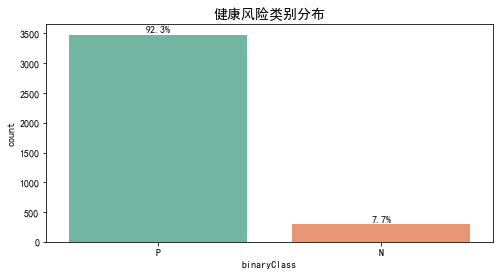

In [423]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='binaryClass', data=train_data, palette='Set2')
plt.title('健康风险类别分布', fontsize=14)

# 添加百分比标签
total = len(train_data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.show()

#### 1.3.2 数值特征分布（直方图 + KDE）

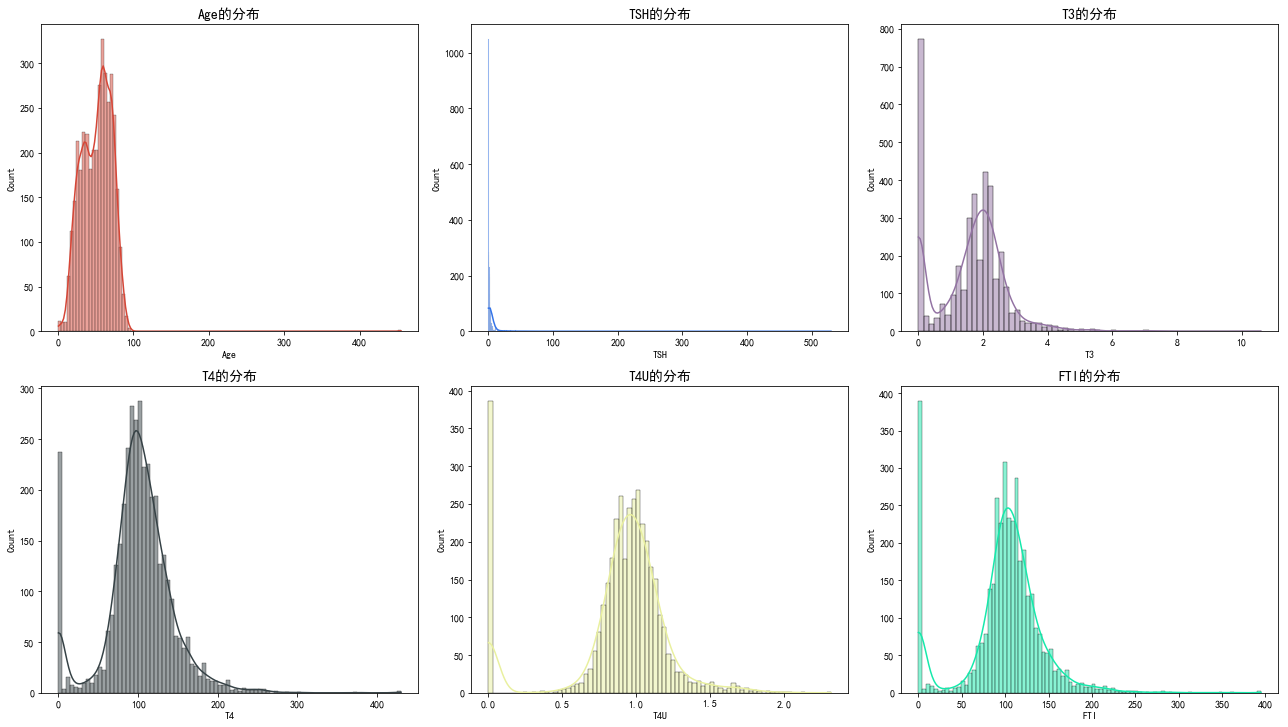

In [424]:
# ------------------------ 所有数据 ----------------------------
# 创建分布矩阵
fig, axes = plt.subplots(10, 3, figsize=(18, 50)) # 2行3列的子图
axes = axes.ravel() # 将轴数组展平

for i, col in enumerate(num_cols):
    sns.histplot(data=train_data, x=col, kde=True, ax=axes[i],color=np.random.rand(3,)) # kde=True 增加密度曲线
    axes[i].set_title(f'{col}的分布', fontsize=14)
    
# 如果子图数量多于特征，隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

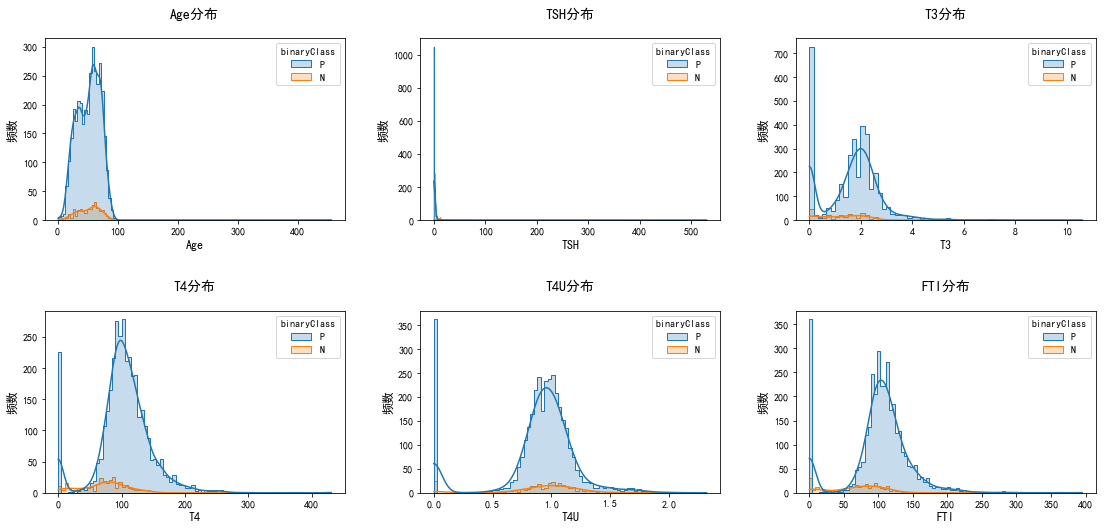

In [428]:
# ------------------------ 按标签分类 ----------------------------
# 绘制分布矩阵---数值类型
if 'binaryClass' in true_numeric_cols:
    true_numeric_cols.remove('binaryClass')

# 计算需要的行数和列数
n_features = len(num_cols)
n_cols = 3  # 每行3个子图
n_rows = (n_features + n_cols - 1) // n_cols  # 向上取整

# # 绘制分布矩阵
plt.figure(figsize=(16, 4 * n_rows))  # 根据行数动态调整高度
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(data=train_data, x=col,kde=True, hue='binaryClass', element='step')
    plt.title(f'{col}分布', fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('频数', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

#### 1.3.3 类别特征分布

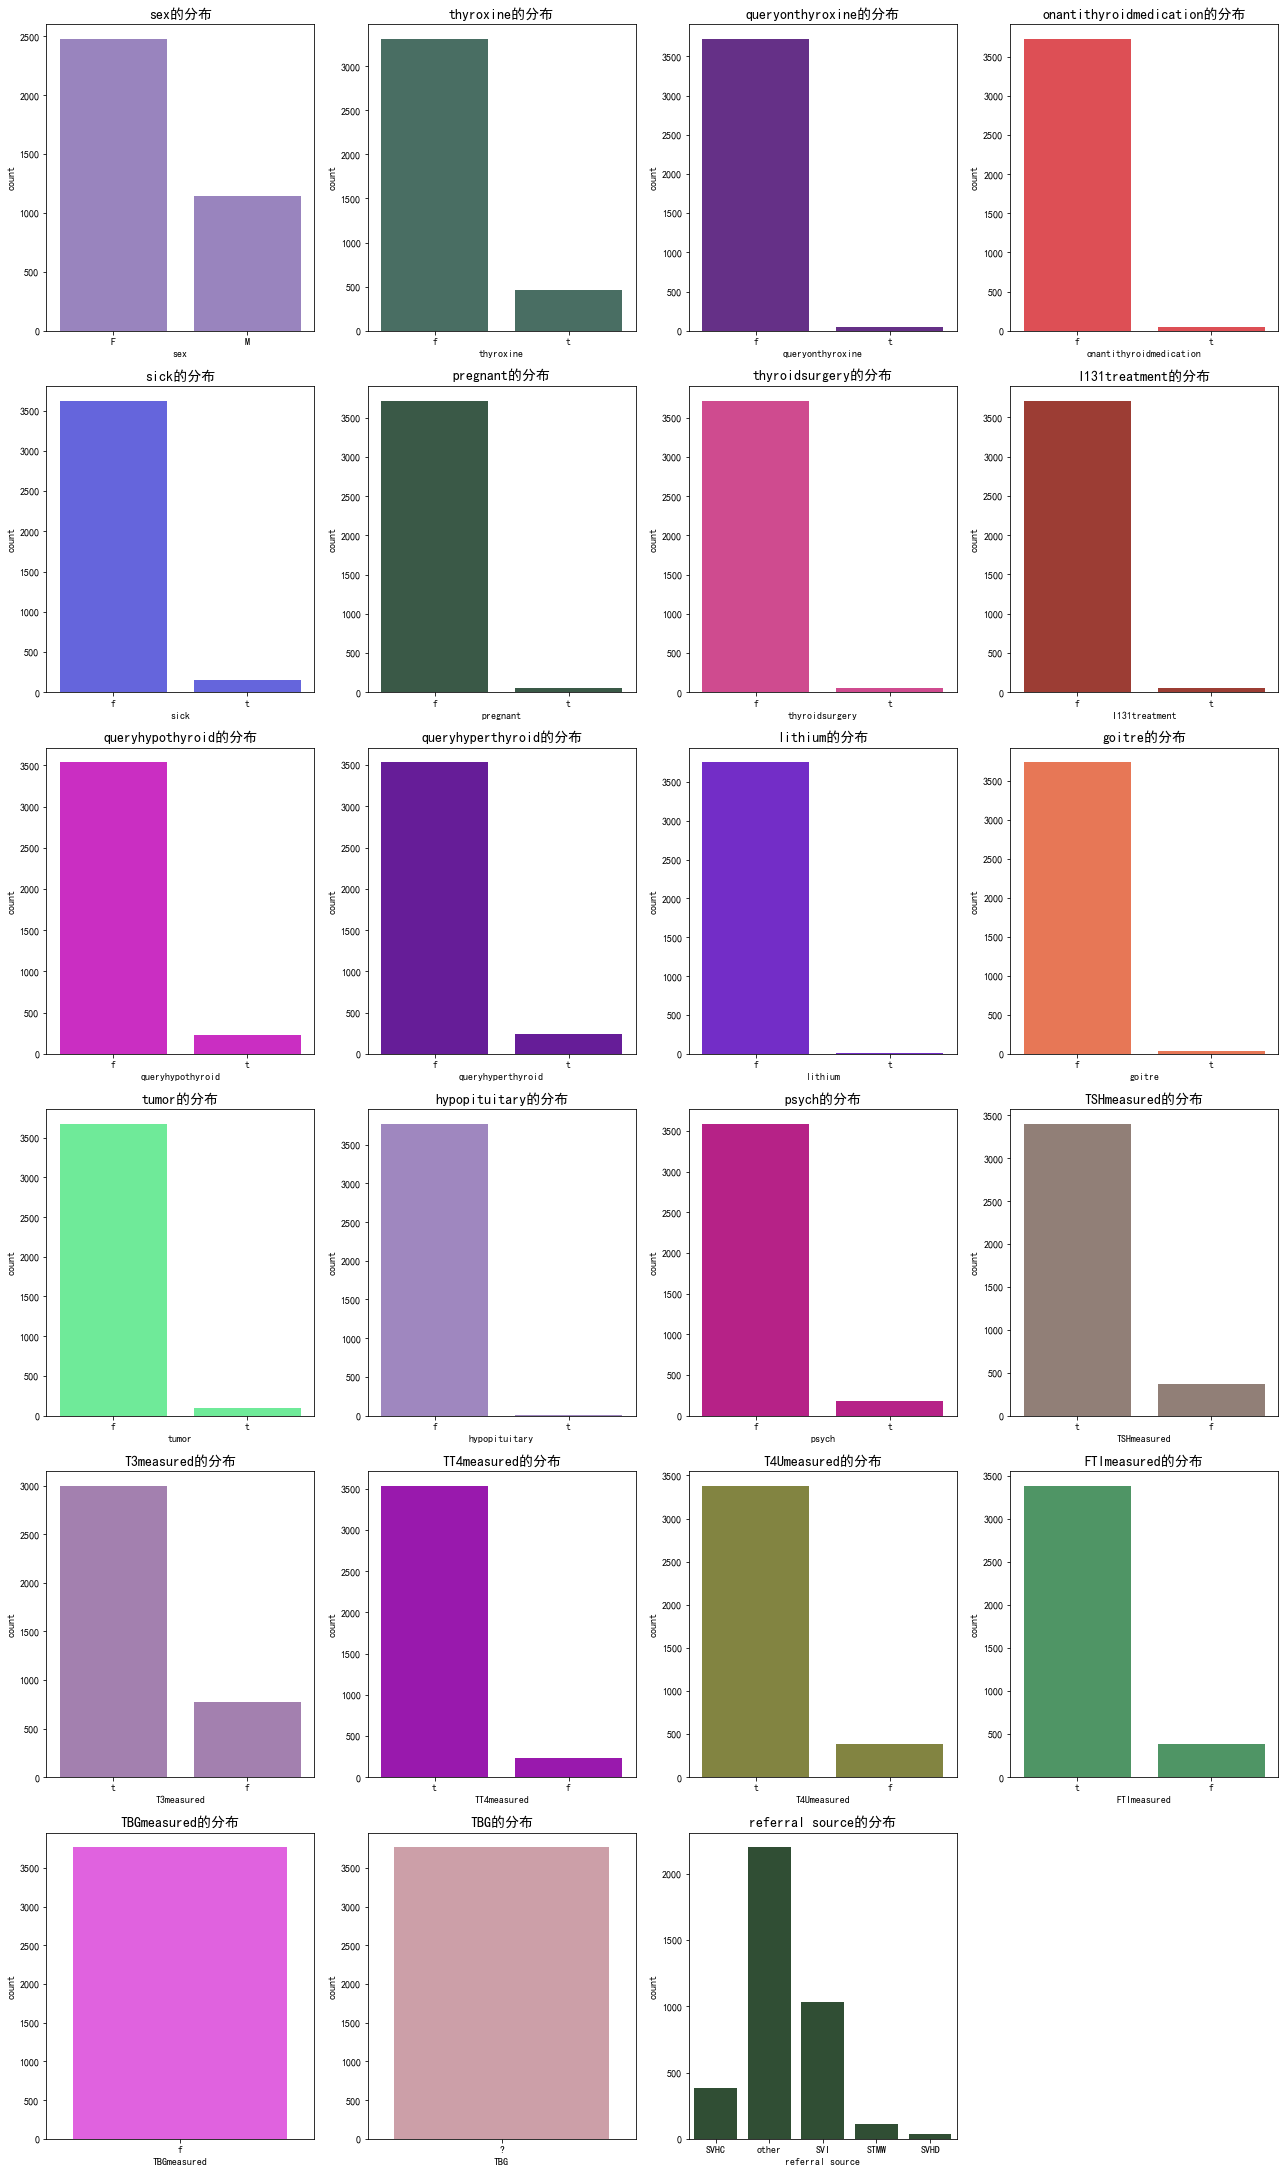

In [429]:
# ------------------------ 所有数据 ----------------------------
# 创建分布矩阵
fig, axes = plt.subplots(10, 4, figsize=(18, 50)) # 2行3列的子图
axes = axes.ravel() # 将轴数组展平

for i, col in enumerate(categorical_cols ):
    sns.countplot(data=train_data, x=col,ax=axes[i],color=np.random.rand(3,))
    axes[i].set_title(f'{col}的分布', fontsize=14)
    
# 如果子图数量多于特征，隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

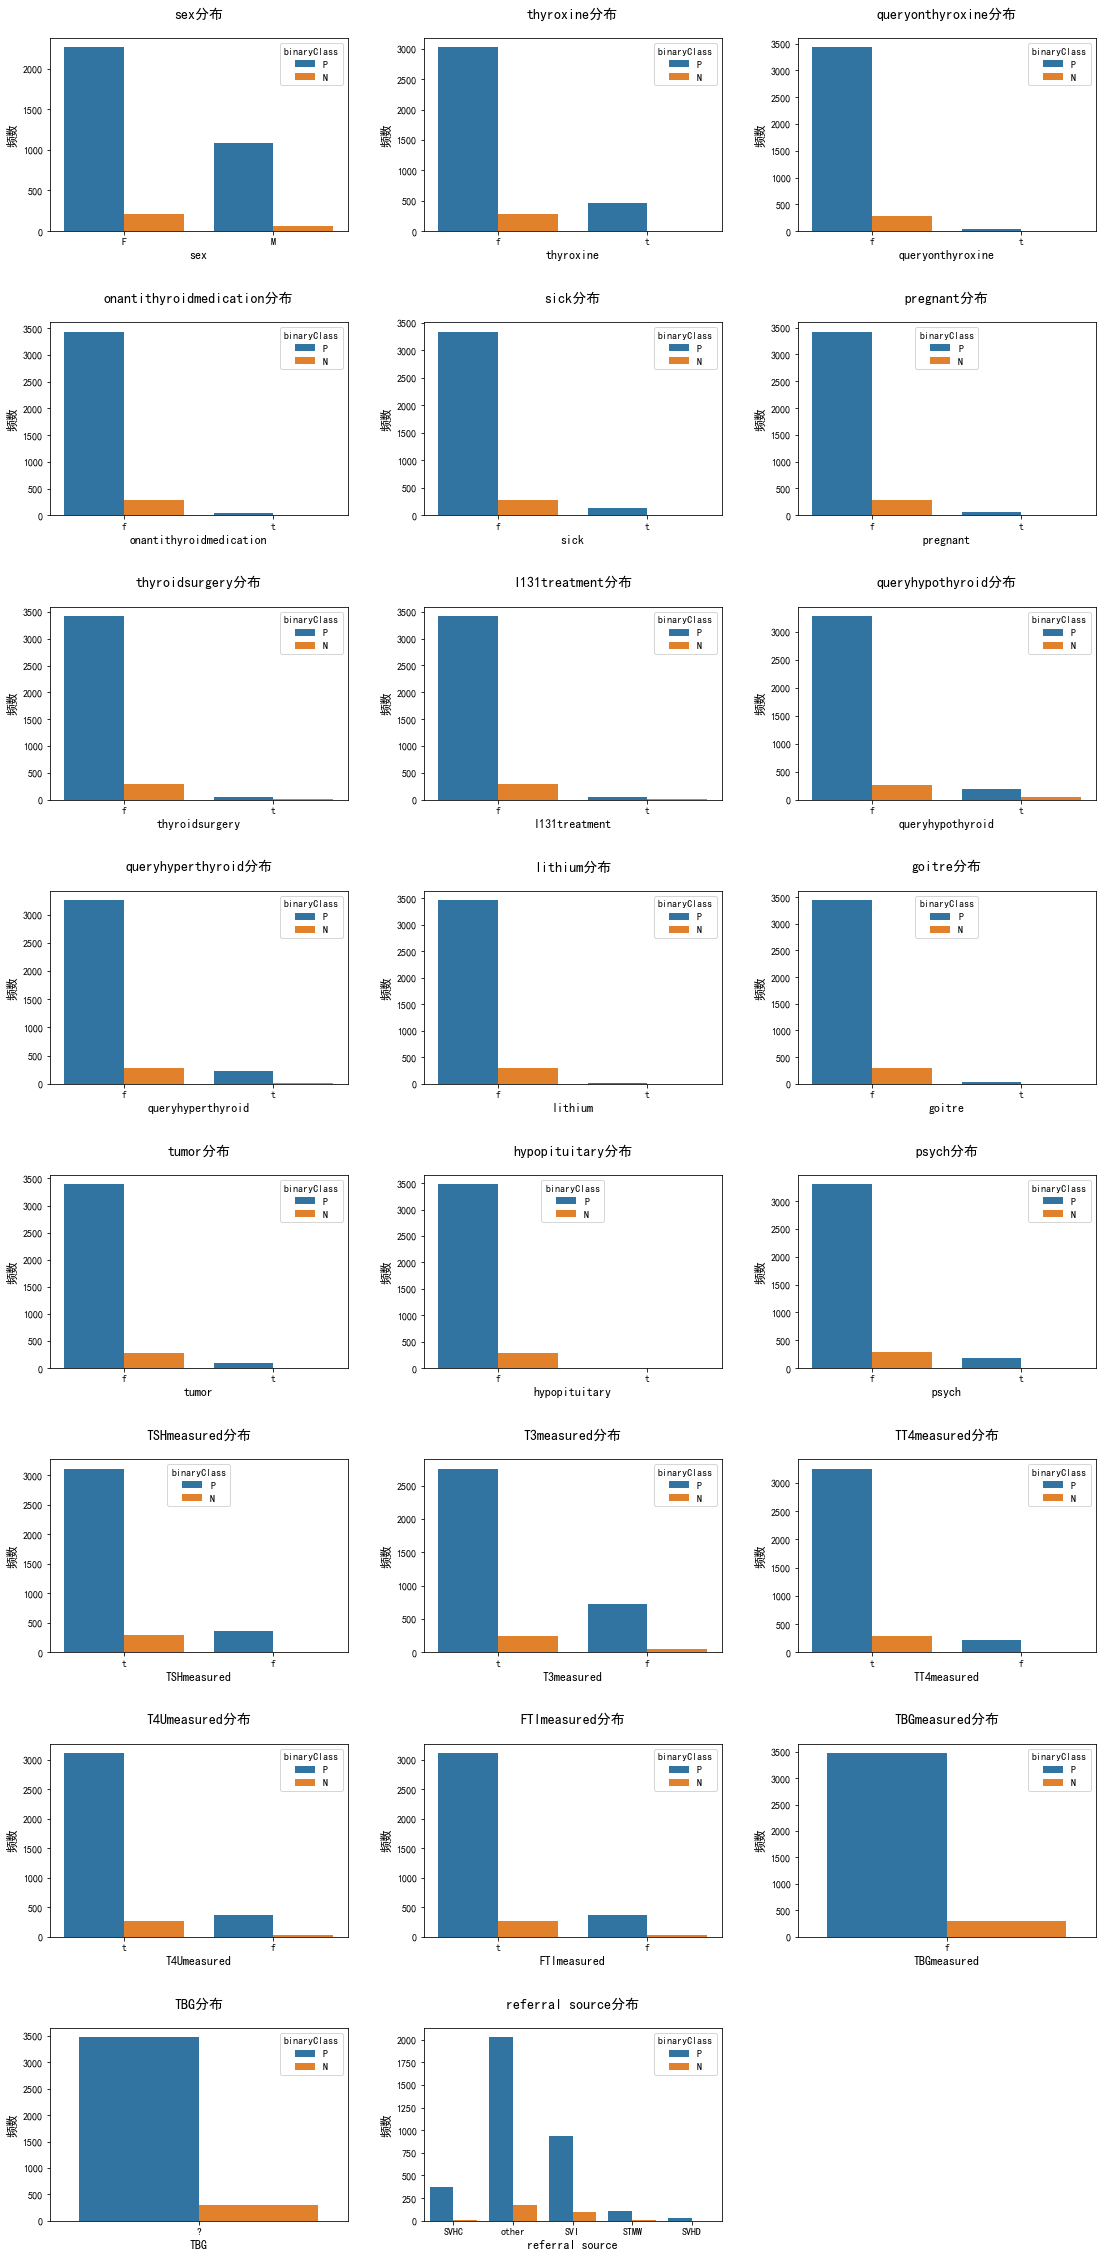

In [430]:
# ------------------------ 按标签分类 ----------------------------
# 绘制分布矩阵-

# 计算需要的行数和列数
n_features = len(categorical_cols)
n_cols = 3  # 每行3个子图
n_rows = (n_features + n_cols - 1) // n_cols  # 向上取整

# # 绘制分布矩阵
plt.figure(figsize=(16, 4 * n_rows))  # 根据行数动态调整高度
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=train_data, x=col,hue='binaryClass')
    plt.title(f'{col}分布', fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('频数', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

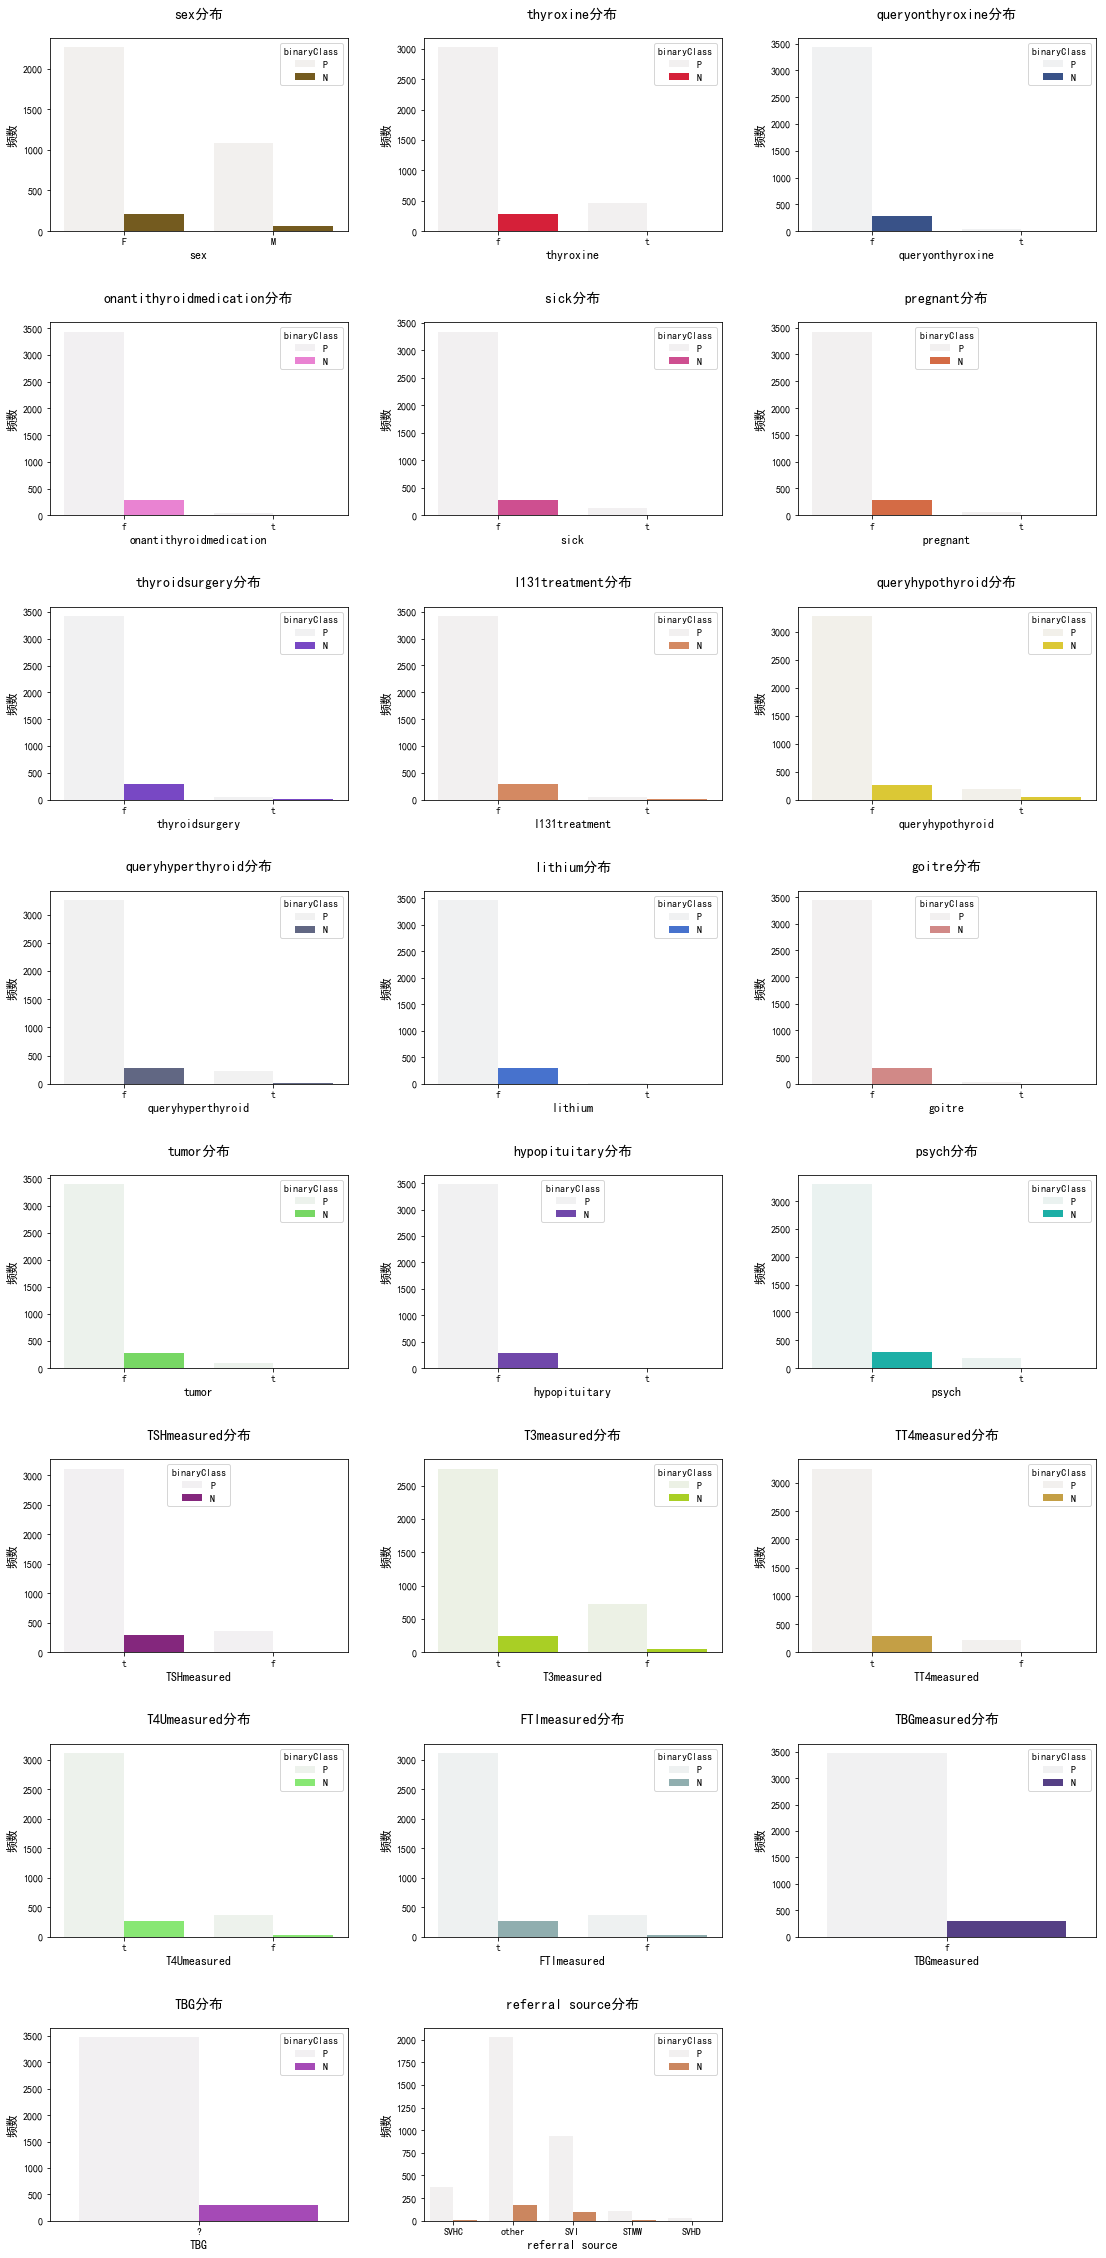

In [431]:
# ------------------------ 按标签分类 ----------------------------
# 绘制分布矩阵-

# 计算需要的行数和列数
n_features = len(categorical_cols)
n_cols = 3  # 每行3个子图
n_rows = (n_features + n_cols - 1) // n_cols  # 向上取整

# # 绘制分布矩阵
plt.figure(figsize=(16, 4 * n_rows))  # 根据行数动态调整高度
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i+1)

    sns.countplot(data=train_data, x=col,hue='binaryClass',color=np.random.rand(3,))
    plt.title(f'{col}分布', fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('频数', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

#### 1.3.4 数值特征分布形态（箱线图）

In [257]:
# # 绘制数值类型特征的箱线图1.0
# plt.figure(figsize=(15, 20))
# plt.boxplot(train_df[true_numeric_cols].T, labels=true_numeric_cols, vert=False)
# plt.title('数值特征箱线图', fontsize=14)
# plt.xlabel('特征数值')
# plt.tight_layout()
# plt.show()

In [258]:
# # # 绘制数值类型特征的箱线图2.0 --- 对数尺度
# plt.figure(figsize=(15, 20))
# log_data = np.log1p(train_df[true_numeric_cols])  # log1p处理0值
# plt.boxplot(log_data.T, labels=true_numeric_cols, vert=False)
# plt.title('数值特征箱线图', fontsize=16)
# plt.title('数值特征箱线图（对数尺度）')
# plt.xlabel('log(数值 + 1)')
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.grid(axis='x', alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.show()

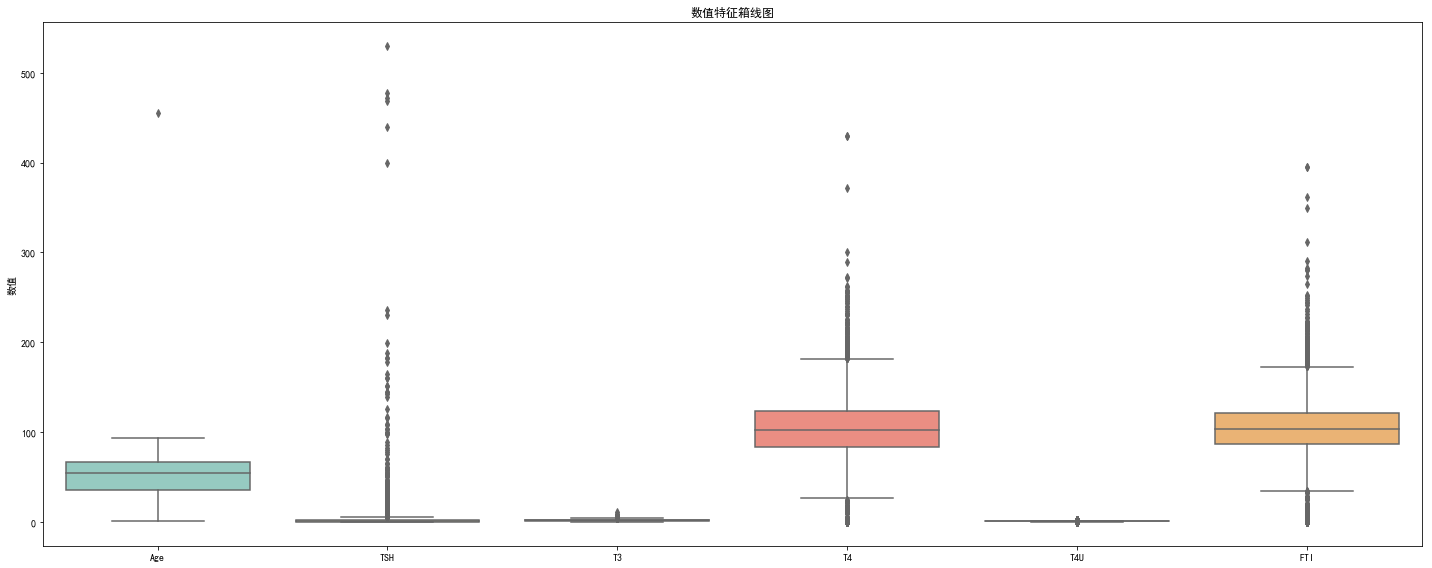

In [432]:
# 1. 选择需要绘制箱线图的特征（排除可能包含0或负值的列）
features_to_plot = [col for col in num_cols if (train_data[col] >= 0).all()]

# 2. 创建图形
plt.figure(figsize=(20, 8))

# 3. 绘制箱线图
sns.boxplot(data=train_data[features_to_plot], palette='Set3')  

# 4. 设置标题和标签（与原始图保持一致格式）
plt.title('数值特征箱线图')
plt.ylabel('数值')

# 5. 优化布局
plt.tight_layout()

# 6. 显示图形
plt.show()

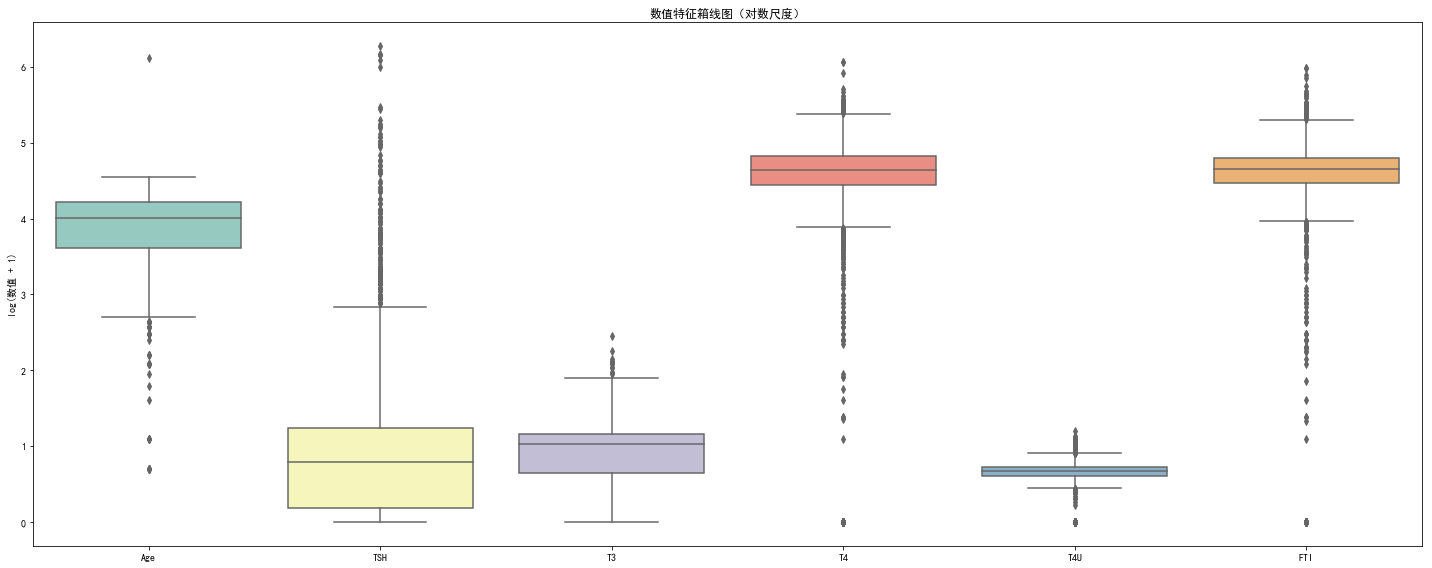

In [433]:
# 1. 选择需要绘制箱线图的特征（排除可能包含0或负值的列）
features_to_plot = [col for col in num_cols if (train_data[col] >= 0).all()]

# 2. 创建图形
plt.figure(figsize=(20, 8))  # 保持与原始图相同的尺寸

# 3. 绘制箱线图（使用对数尺度）
# 对处理后的数据应用 log(1+x) 转换
sns.boxplot(data=np.log1p(train_data[features_to_plot]), palette='Set3') 

# 4. 设置标题和标签（与原始图保持一致格式）
plt.title('数值特征箱线图（对数尺度）')
plt.ylabel('log(数值 + 1)')

# 5. 优化布局
plt.tight_layout()

# 6. 显示图形
plt.show()

## 2. 第一轮预处理
目的：解决数据探索中发现的明显缺陷，为后续深入分析做准备

### 2.1 处理异常值

In [434]:
train_df = train_data.copy()

#### 使用IQR（四分位距）方法检测数据中异常值

In [435]:
# 检查异常值

In [436]:
def outlier_thresholds(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def check_outliers(data, col):
    lower, upper = outlier_thresholds(data, col)
    return data[(data[col] < lower) | (data[col] > upper)]

print('异常列\t\t异常值数量')
for col in num_cols:
    print(f"{col.ljust(20)}\t{len(check_outliers(train_df, col))}")

异常列		异常值数量
Age                 	1
TSH                 	376
T3                  	61
T4                  	397
T4U                 	521
FTI                 	561


#### 检测并替换指定列中的异常值为该列的中位数

In [437]:
def replace_outliers_with_median(data, col):
    lower, upper = outlier_thresholds(data, col)
    median = data[col].median()
    data[col] = np.where((data[col] < lower) | (data[col] > upper), median, data[col])

for col in num_cols:
    replace_outliers_with_median(train_df, col)

#### 查看替换异常值后的箱线图

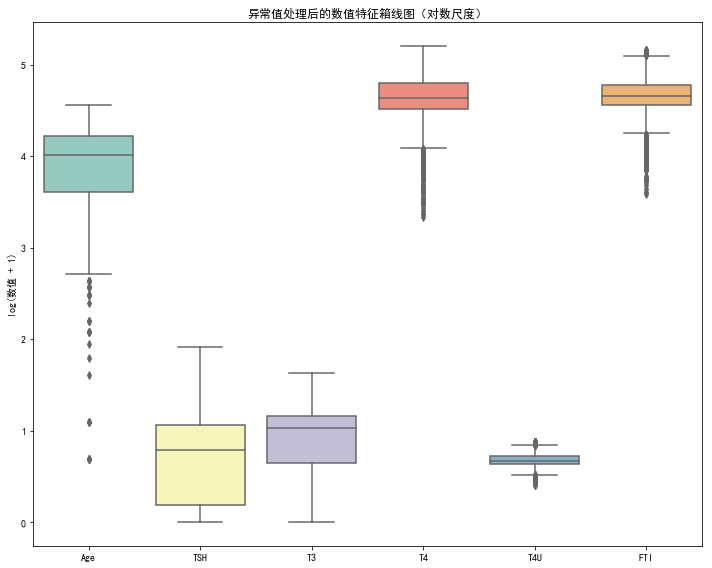

In [438]:
# 1. 选择需要绘制箱线图的特征（排除可能包含0或负值的列）
features_to_plot = [col for col in num_cols if (train_df[col] >= 0).all()]


plt.figure(figsize=(10, 8))  

# 3. 绘制箱线图（使用对数尺度）
sns.boxplot(data=np.log1p(train_df[features_to_plot]), palette='Set3')  

# 4. 设置标题和标签（与原始图保持一致格式）
plt.title('异常值处理后的数值特征箱线图（对数尺度）')
plt.ylabel('log(数值 + 1)')

# 5. 优化布局
plt.tight_layout()

# 6. 显示图形
plt.show()

### 2.2 处理重复行

In [439]:
print(f"去重前数据形状: {train_df.shape}")

# 删除完全重复的行
train_df_clean = train_df.drop_duplicates()

print(f"去重后数据形状: {train_df_clean.shape}")
print(f"删除了 {len(train_df) - len(train_df_clean)} 个重复行")

去重前数据形状: (3770, 30)
去重后数据形状: (3709, 30)
删除了 61 个重复行


In [440]:
train_df = train_df_clean

### 2.3 处理空值

In [441]:
# 连续数值特征用中位数填充
if num_cols:
    train_df[num_cols] = train_df[num_cols].fillna(train_df[num_cols].median())
    print("连续数值特征缺失值已用中位数填充")

连续数值特征缺失值已用中位数填充


In [442]:
# 分类型特征用众数填充
if categorical_cols:
    for col in categorical_cols:
        if train_df[col].notna().any():
            mode_val = train_df[col].mode()[0] if not train_df[col].mode().empty else "MISSING"
            train_df[col] = train_df[col].fillna(mode_val)
    print("分类特征缺失值已用众数填充")

分类特征缺失值已用众数填充


In [443]:
# 检查是否填充完整
print("缺失值统计:\n", train_df.isnull().sum().sort_values(ascending=False).head(10))

缺失值统计:
 binaryClass                0
referral source            0
sex                        0
thyroxine                  0
queryonthyroxine           0
onantithyroidmedication    0
sick                       0
pregnant                   0
thyroidsurgery             0
I131treatment              0
dtype: int64


#### 缺失值处理效果验证

### 2.4 分离目标变量

In [452]:
# 分离目标变量
y = train_df.pop('binaryClass')   # 删除列名指定的列,同时将结果返回到y_train

In [445]:
# print(f"删除前列数: {train_df.shape[1]}")

# # 找出所有值完全相同的列（包括全NaN的列）
# constant_columns = []
# for col in train_df.columns:
#     if train_df[col].nunique() <= 1:  # 只有1个或0个唯一值
#         constant_columns.append(col)

# # 删除这些列
# train_df = train_df.drop(columns=constant_columns)

# print(f"删除后列数: {train_df.shape[1]}")
# print(f"删除的列: {constant_columns}")

## 3. 进一步数据探索
目的：理解数据分布、模式和关系，为特征工程提供依据。

### 3.1 计算相关系数矩阵（发现多重共线性）

In [453]:
train_corr = train_df[num_cols].corr()
train_corr

,Age,TSH,T3,T4,T4U,FTI
Age,1.000000,0.026913,-0.097860,-0.014615,-0.107804,0.070173
TSH,0.026913,1.000000,0.040006,-0.138876,0.022600,-0.160441
T3,-0.097860,0.040006,1.000000,0.174514,0.197573,0.008230
T4,-0.014615,-0.138876,0.174514,1.000000,0.351770,0.646689
T4U,-0.107804,0.022600,0.197573,0.351770,1.000000,-0.148435
FTI,0.070173,-0.160441,0.008230,0.646689,-0.148435,1.000000


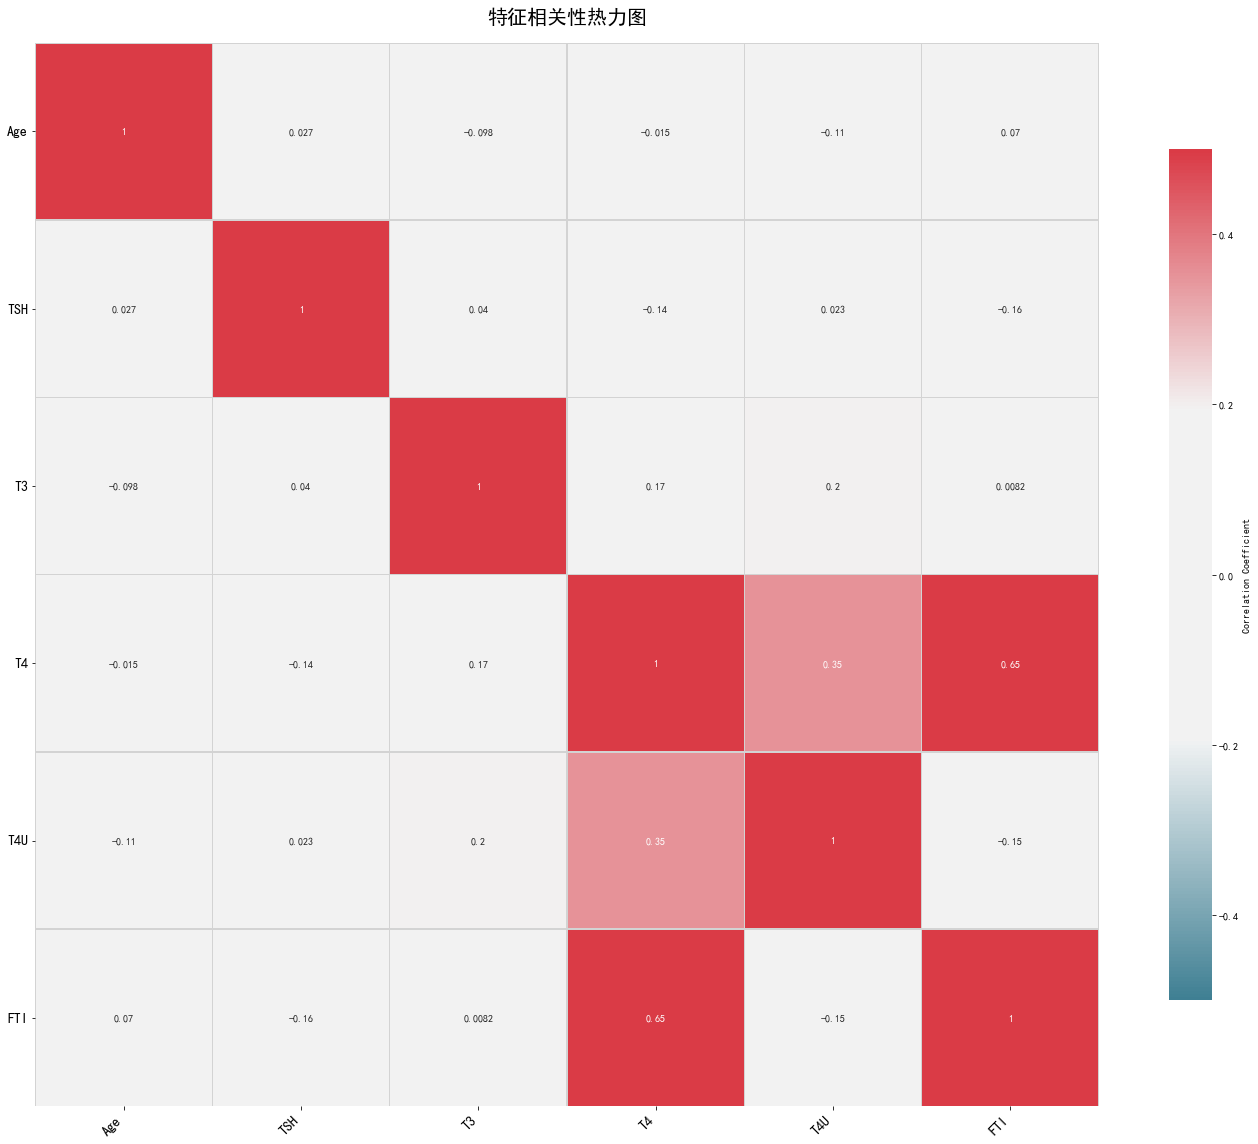

In [454]:
# 绘制相关性热力图
plt.figure(figsize=(20, 16))

# 创建自定义的颜色映射，从蓝色（负相关）到白色（零相关）到红色（正相关）
custom_cmap = sns.diverging_palette(220, 10, as_cmap=True, sep=100, center='light')

# 绘制热力图
ax = sns.heatmap(train_corr, vmin=-0.5,vmax=0.5,square=True, annot=True,cmap=custom_cmap,linewidths=0.5,linecolor='lightgray',
                 cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})

plt.title("特征相关性热力图", fontsize=20, fontweight='bold', pad=20)  # 添加标题
plt.xticks(rotation=45, ha='right', fontsize=14)  # 旋转x轴标签，避免重叠
plt.yticks(rotation=0, fontsize=14)  # 保持y轴标签水平

ax.grid(False)  # 添加网格线，提高可读性
plt.tight_layout()  # 调整布局，确保所有元素都能显示
plt.show()


In [455]:
# 找出相关性>0.8的特征对
high_corr_pairs = []
for i in range(len(train_corr.columns)):
    for j in range(i+1, len(train_corr.columns)):  # 只遍历上三角矩阵避免重复
        if train_corr.iloc[i, j] > 0.8:
            col1, col2 = train_corr.columns[i], train_corr.columns[j]
            high_corr_pairs.append((col1, col2, train_corr.iloc[i, j]))
            
# 打印高相关特征对报告
print("\n高相关特征对报告（相关系数 > 0.8）:")
print("="*50)
for i, (col1, col2, corr) in enumerate(high_corr_pairs, 1):
    print(f"{i}. {col1} 与 {col2}: {corr:.4f}")
    
    # 显示特征描述（如果有）
    if 'feature_descriptions' in locals():
        desc1 = feature_descriptions.get(col1, "无描述")
        desc2 = feature_descriptions.get(col2, "无描述")
        print(f"   - {col1}: {desc1}")
        print(f"   - {col2}: {desc2}")
    
    # 显示基本统计量对比
    print(f"   - {col1} 均值: {train_df[col1].mean():.2f} ± {train_df[col1].std():.2f}")
    print(f"   - {col2} 均值: {train_df[col2].mean():.2f} ± {train_df[col2].std():.2f}")
    print("-"*50)
            


高相关特征对报告（相关系数 > 0.8）:


In [456]:
# # 删除高度相关的特征
# train_df1 = train_df.drop(['bmi_estimated','bmi_scaled','bmi_corrected'],axis=1)

In [457]:
# train_df1

### 3.2 筛选与目标值相关性最高的10个特征

#### 3.2.1 用Pearson相关系数进行评估

已添加目标变量列：binaryClass，数据类型：int8
目标变量非缺失样本数：3709


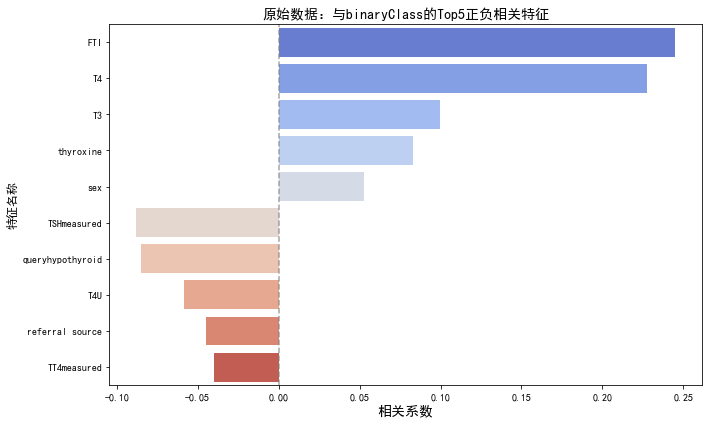

In [458]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# 全局字体设置（确保中文正常显示）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# 2. 特征与目标变量相关性可视化
def plot_target_corr(df, y, target_col_name="binaryClass"):
    # 关键检查1：确保目标变量非空
    if y.isnull().all():
        raise ValueError("目标变量y全为缺失值，无法计算相关性")
    if len(y) != len(df):
        raise ValueError(f"目标变量与特征数量不匹配：y有{len(y)}个样本，df有{len(df)}个样本")
    
    # 1. 复制原始数据并创建临时数据集
    df_temp = df.copy()
    
    # 2. 处理类别特征（确保编码后为数值型）
    le = LabelEncoder()
    for col in categorical_cols:
            df_temp[col] = le.fit_transform(df_temp[col])
    
    # 3. 强制添加目标变量（确保数据类型匹配）
    df_temp[target_col_name] = y.astype('category').cat.codes  # 转为数值编码，确保能参与计算
    print(f"已添加目标变量列：{target_col_name}，数据类型：{df_temp[target_col_name].dtype}")
    print(f"目标变量非缺失样本数：{df_temp[target_col_name].notna().sum()}")
    
    # 4. 计算相关矩阵（使用pearson方法，显式处理缺失值）
    corr_matrix = df_temp.corr(method='pearson', min_periods=1)  # min_periods=1允许最少1个非缺失值计算
    
    # 关键检查2：确认目标变量在相关矩阵中
    if target_col_name not in corr_matrix.columns:
        # 输出调试信息
        print("相关矩阵列名：", corr_matrix.columns.tolist())
        print("临时数据集中的列：", df_temp.columns.tolist())
        raise ValueError(f"目标变量列 {target_col_name} 未出现在相关矩阵中，请检查数据")
    
    # 5. 提取目标变量与特征的相关性
    target_corr = corr_matrix[target_col_name].drop(target_col_name, errors='ignore')
    
    # 6. 处理特征不足的情况
    if len(target_corr) == 0:
        print("没有可用于计算相关性的特征")
        return
    
    # 7. 筛选Top相关特征（根据实际数量调整）
    n = min(5, len(target_corr))  # 若特征不足5个，取实际数量
    top_positive = target_corr.sort_values(ascending=False).head(n)
    top_negative = target_corr.sort_values().head(n)
    top_corr = pd.concat([top_positive, top_negative])
    
    # 8. 绘制相关性条形图
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    plt.title(f"原始数据：与{target_col_name}的Top{n}正负相关特征", fontsize=14)
    plt.xlabel("相关系数", fontsize=14)
    plt.ylabel("特征名称", fontsize=12)
    plt.tight_layout()
    plt.show()
    

# 3. 调用修复后的函数
try:
    plot_target_corr(train_df, y)
except Exception as e:
    print(f"执行出错：{str(e)}")

#### 3.2.2 用互信息得分进行评估

In [459]:
train_df.head()

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,T3,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source
0,12.0,F,f,f,f,f,f,f,f,f,...,2.5,t,125.0,t,1.14,t,109.0,f,?,SVHC
1,20.0,M,f,f,f,f,f,f,f,f,...,2.0,t,102.0,f,0.95,f,104.0,f,?,other
2,46.0,M,f,f,f,f,f,f,f,f,...,0.0,t,109.0,t,0.91,t,120.0,f,?,other
3,70.0,F,t,f,f,f,f,f,f,f,...,1.9,t,175.0,f,0.95,f,104.0,f,?,other
4,70.0,F,f,f,f,f,f,f,f,f,...,1.2,t,61.0,t,0.87,t,70.0,f,?,SVI


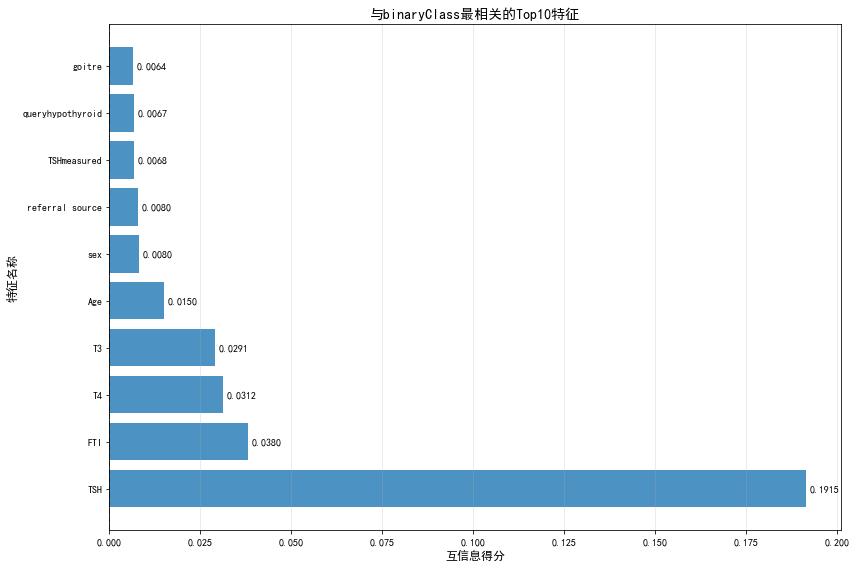

特征相关性排名:
TSH                 0.191495
FTI                 0.038035
T4                  0.031219
T3                  0.029148
Age                 0.015005
sex                 0.007987
referral source     0.007974
TSHmeasured         0.006841
queryhypothyroid    0.006705
goitre              0.006388
dtype: float64


In [460]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# 全局字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def plot_target_corr(df, y, target_col_name="binaryClass", n_top=10):
    # 1. 数据验证
    if y.isnull().all():
        raise ValueError("目标变量y全为缺失值，无法计算相关性")
    if len(y) != len(df):
        raise ValueError(f"目标变量与特征数量不匹配：y有{len(y)}个样本，df有{len(df)}个样本")
    
    # 2. 复制数据并处理
    df_temp = df.copy()
    
    # 4. 编码分类特征
    le = LabelEncoder()
    for col in categorical_cols:
        df_temp[col] = le.fit_transform(df_temp[col])
    
    # 5. 确保所有特征都是数值型
    for col in df_temp.columns:
        if df_temp[col].dtype == 'object':
            try:
                df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce').fillna(-1)
            except:
                print(f"警告: 无法将列 {col} 转换为数值型，尝试标签编码")
                df_temp[col] = le.fit_transform(df_temp[col].astype(str))
    
    # 6. 编码目标变量（不添加到DataFrame中）
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    
    # 7. 计算互信息得分
    try:
        mi_scores = mutual_info_classif(df_temp, y_encoded, random_state=42)
        target_corr = pd.Series(mi_scores, index=df_temp.columns)
    except Exception as e:
        print(f"互信息计算失败: {e}")
        print("尝试备用方法...")
        # 备用方法：临时添加目标变量计算Pearson相关系数
        temp_df = df_temp.copy()
        temp_df[target_col_name] = y_encoded
        corr_matrix = temp_df.corr(method='pearson', numeric_only=True)
        target_corr = corr_matrix[target_col_name].drop(target_col_name, errors='ignore')
    
    # 8. 筛选Top相关特征（确保不包含目标变量）
    if len(target_corr) == 0:
        print("没有可用于计算相关性的特征")
        return
    
    # 确保目标变量列不在结果中
    target_corr = target_corr.drop(target_col_name, errors='ignore')
    
    n = min(n_top, len(target_corr))
    top_features = target_corr.nlargest(n)
    
    # 9. 绘制相关性条形图
    plt.figure(figsize=(12, 8))
    
    # 设置颜色（互信息只有正值）
    colors = ['#1f77b4' for _ in range(len(top_features))]
    
    # 创建水平条形图
    bars = plt.barh(top_features.index, top_features.values, color=colors, alpha=0.8)
    
    # 添加数值标签
    for i, (feature, value) in enumerate(zip(top_features.index, top_features.values)):
        plt.text(value + 0.001, i, f'{value:.4f}', va='center', fontsize=10, fontweight='bold')
    
    # 美化图表
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    plt.xlabel('互信息得分' if 'mi_scores' in locals() else '相关系数', fontsize=12, fontweight='bold')
    plt.ylabel('特征名称', fontsize=12, fontweight='bold')
    plt.title(f'与{target_col_name}最相关的Top{n}特征', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 10. 返回相关性结果（确保不包含目标变量）
    return target_corr.sort_values(ascending=False),top_features

# 使用示例
try:
    # 调用函数
    correlation_results,top_features = plot_target_corr(
        train_df, 
        y, 
        target_col_name="binaryClass",
        n_top=10
    )
    
    # 打印结果（已自动排除目标变量）
    print("特征相关性排名:")
    print(correlation_results.head(10))
    
except Exception as e:
    print(f"执行出错：{str(e)}")
    import traceback
    traceback.print_exc()

In [461]:
x = top_features.index.tolist()
x

['TSH',
 'FTI',
 'T4',
 'T3',
 'Age',
 'sex',
 'referral source',
 'TSHmeasured',
 'queryhypothyroid',
 'goitre']

### 3.3 关键特征与目标变量关系

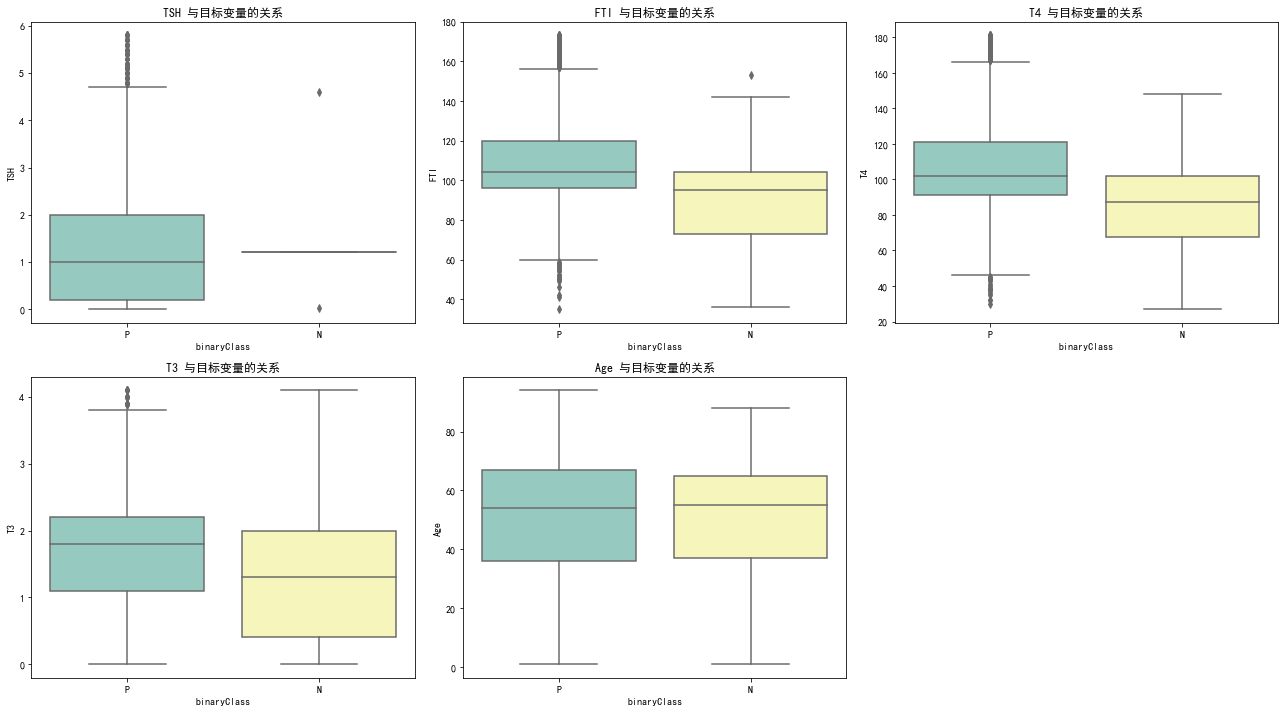

In [462]:
key_features = top_features.index.tolist()
key_features = [f for f in key_features if f in num_cols]

plt.figure(figsize=(18, 10))
for i, feature in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        y=train_df[feature], 
        x=y,  # 将目标变量放在x轴更直观
        palette='Set3'
    )
    plt.title(f'{feature} 与目标变量的关系', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 数据处理前后的数值特征分布

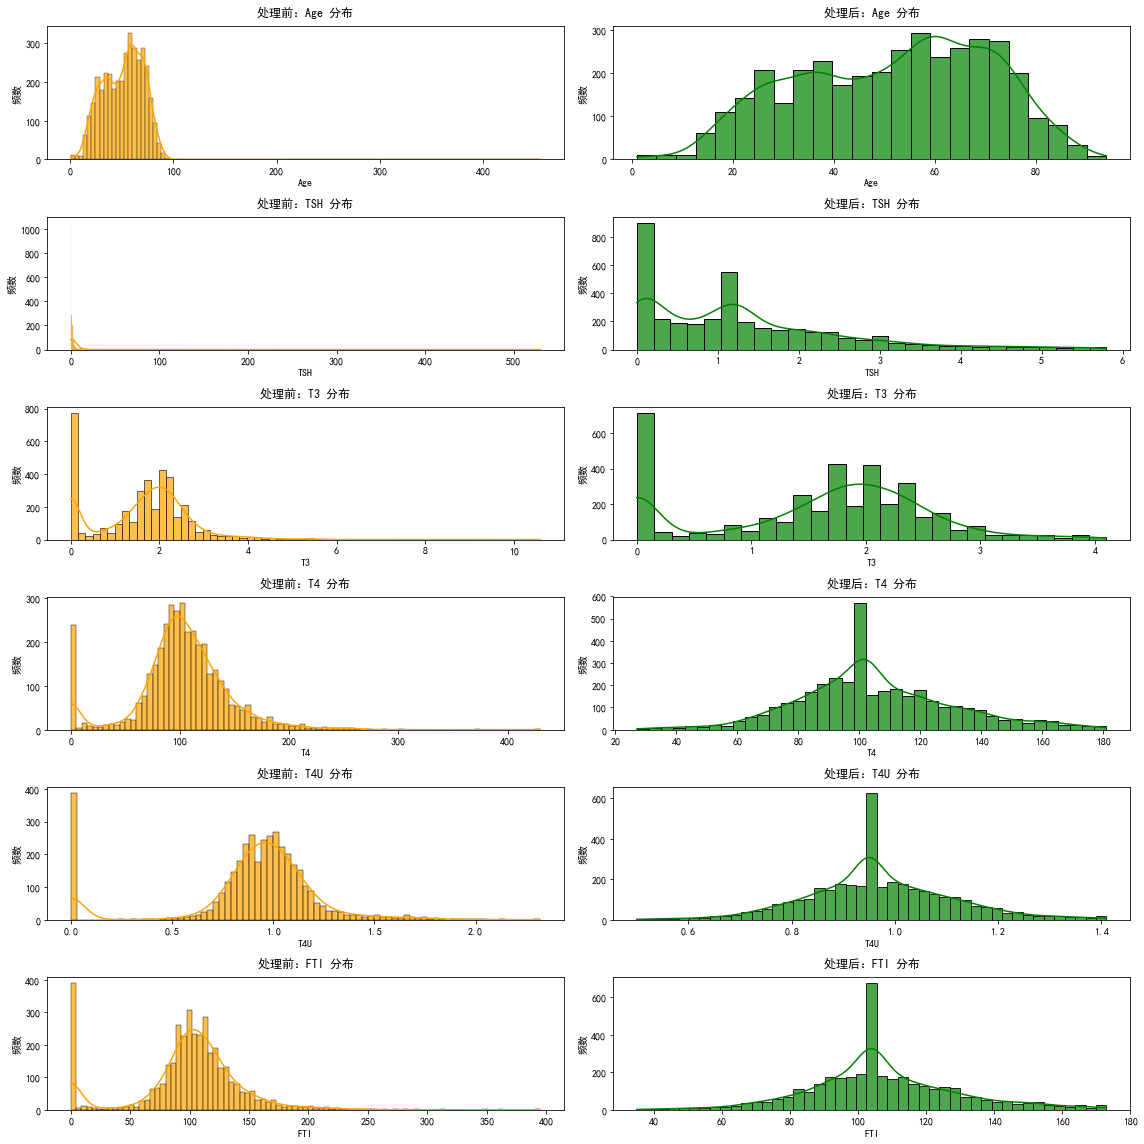

In [464]:
def validate_features_and_data(df, df_name, features):
    """校验数据集和特征是否合法"""
    # 校验数据集
    if not isinstance(df, pd.DataFrame):
        raise ValueError(f"「{df_name}」不是pandas DataFrame！请检查数据加载")
    if df.empty:
        raise ValueError(f"「{df_name}」是空数据集！")
    # 校验特征是否存在于数据集
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"「{df_name}」中缺少特征：{', '.join(missing_features)}")
# 1. 定义待对比的特征
compare_features = num_cols
plt.figure(figsize=(16, 16))  # 增大画布高度，避免子图拥挤
for i, feature in enumerate(compare_features, 1):
    # 处理前分布：第i行第1列（索引 = (i-1)*2 + 1）
    plt.subplot(len(compare_features), 2, (i-1)*2 + 1)
    sns.histplot(
        train_data[feature].dropna(),  # 处理前：删除缺失值
        kde=True,  # 显示核密度曲线，更清晰看分布趋势
        color='orange',
        edgecolor='black',  # 添加条形边框，避免颜色混叠
        alpha=0.7  # 降低透明度，提升视觉舒适度
    )
    plt.title(f'处理前：{feature} 分布', fontsize=12, pad=10)
    plt.xlabel(feature, fontsize=10)  # 添加x轴标签，明确特征名
    plt.ylabel('频数', fontsize=10)

    # 处理后分布：第i行第2列（索引 = (i-1)*2 + 2）
    plt.subplot(len(compare_features), 2, (i-1)*2 + 2)
    sns.histplot(
        train_df_selected[feature],  # 处理后：默认无缺失值（假设处理时已填充）
        kde=True,
        color='green',
        edgecolor='black',
        alpha=0.7
    )
    plt.title(f'处理后：{feature} 分布', fontsize=12, pad=10)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('频数', fontsize=10)

# 自动调整子图间距，避免标题/标签重叠
plt.tight_layout()
plt.show()

#### 数据处理后的数值特征分布

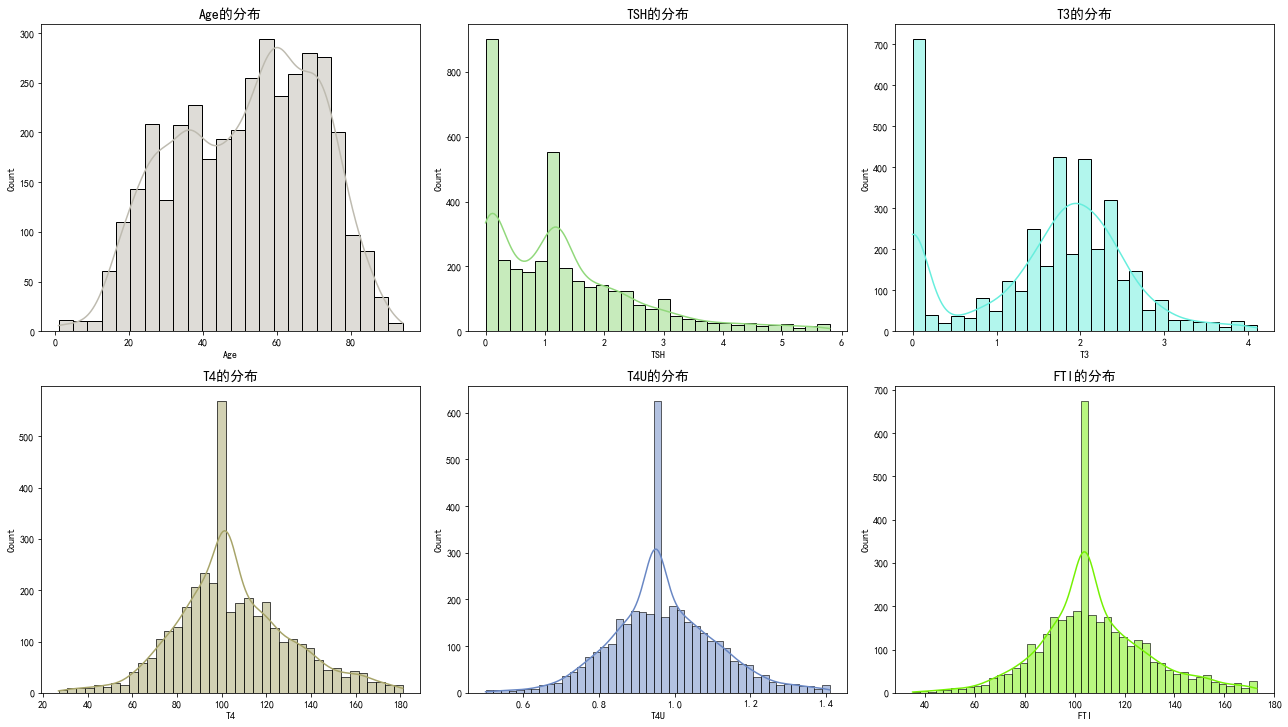

In [465]:
# 数值特征分布（直方图 + KDE）
fig, axes = plt.subplots(10, 3, figsize=(18, 50)) # 2行3列的子图
axes = axes.ravel() # 将轴数组展平

for i, col in enumerate(num_cols):
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[i],color=np.random.rand(3,)) # kde=True 增加密度曲线
    axes[i].set_title(f'{col}的分布', fontsize=14)
    
# 如果子图数量多于特征，隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

## 4. 特征工程

In [467]:
# # 分离目标变量
# y = train_df.pop('binaryClass')   # 删除列名指定的列,同时将结果返回到y_train

### 文本特征进行One-Hot编码

In [468]:
# 文本特征进行One-Hot编码
if text_cols:
    train_df_new = pd.get_dummies(train_df, columns=text_cols, prefix_sep="::")
    print(f"文本特征One-Hot编码后新增 {len(train_df_new.columns) - len(train_df.columns)} 列")

文本特征One-Hot编码后新增 24 列


In [469]:
train_df_new.shape

(3709, 53)

In [470]:
train_df_new.head()

,Age,TSH,T3,T4,T4U,FTI,sex::F,sex::M,thyroxine::f,thyroxine::t,...,T4Umeasured::t,FTImeasured::f,FTImeasured::t,TBGmeasured::f,TBG::?,referral source::STMW,referral source::SVHC,referral source::SVHD,referral source::SVI,referral source::other
0,12.0,1.30,2.5,125.0,1.14,109.0,1,0,1,0,...,1,0,1,1,1,0,1,0,0,0
1,20.0,4.10,2.0,102.0,0.95,104.0,0,1,1,0,...,0,1,0,1,1,0,0,0,0,1
2,46.0,0.98,0.0,109.0,0.91,120.0,0,1,1,0,...,1,0,1,1,1,0,0,0,0,1
3,70.0,0.16,1.9,175.0,0.95,104.0,1,0,0,1,...,0,1,0,1,1,0,0,0,0,1
4,70.0,0.72,1.2,61.0,0.87,70.0,1,0,1,0,...,1,0,1,1,1,0,0,0,1,0


### 移除方差为0的特征（列值相同）

In [471]:
# 移除方差为0的特征（列值相同）
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
X_selected = selector.fit_transform(train_df_new)

# 重建DataFrame
selected_columns = train_df_new.columns[selector.get_support()]
train_df_selected = pd.DataFrame(X_selected, columns=selected_columns)

print("\n移除方差为0的特征后的DataFrame:")
print(train_df_selected.shape)


移除方差为0的特征后的DataFrame:
(3709, 51)


###  数据处理前后特征数量对比

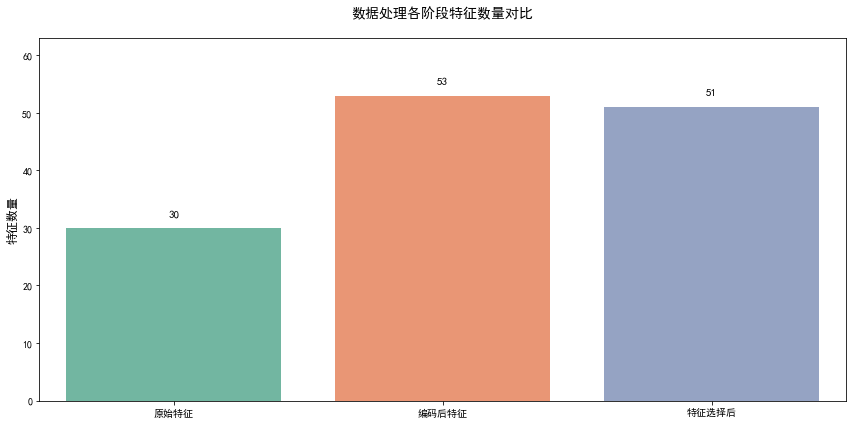

In [481]:
pre_process_features = train_data.shape[1]
post_encoding_features = train_df_new.shape[1]
post_selection_features = train_df_selected.shape[1]

plt.figure(figsize=(12, 6))


sns.barplot(
    x=['原始特征', '编码后特征', '特征选择后'],  # x轴：数据处理阶段
    y=[pre_process_features, post_encoding_features, post_selection_features],  # y轴：特征数量
    palette='Set2',  
)
plt.title('数据处理各阶段特征数量对比', fontsize=14, pad=20)  # pad：标题与图表间距
plt.ylabel('特征数量', fontsize=12)  
plt.ylim(0, max([pre_process_features, post_encoding_features, post_selection_features]) + 10)  # 预留标签空间

# 为每个条形添加“特征数量”标签（避免标签超出画布）
for i, v in enumerate([pre_process_features, post_encoding_features, post_selection_features]):
    plt.text(
        i, v + 2,  # 标签位置：x=条形索引，y=条形顶部+2（避免与条形重叠）
        str(v),    # 标签内容：特征数量
        ha='center', fontsize=11  # 居中对齐，放大字体
    )

plt.tight_layout()  # 自动调整布局，防止标签被截断
plt.show()